In [162]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling, unfocus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

# Making a Forward Model

## Configure a DM

In [163]:
# First we need a forward model of the system
# NOTE: Influence functions should peak at 1

# Basic inputs to a prysm DM
# - influence function
# - number of actuators in X and Y axes
# - separation of the actuators in the array containing the lattice, in units of samples

nact = 22
act_pitch = 3
samples_per_act = 21
sampling_pitch = act_pitch / samples_per_act

x, y = make_xy_grid(512, dx=sampling_pitch)
r, th = cart_to_polar(x, y)
influence_func = gaussian_influence_function(r, act_pitch)#np.sinc(x/act_pitch) * np.sinc(y/act_pitch)
# influence_func /= np.max(influence_func)
Nout = x.shape[0]
dm = DM(influence_func, Nout, nact, samples_per_act, rot=(0,0,0), shift=(0,0))

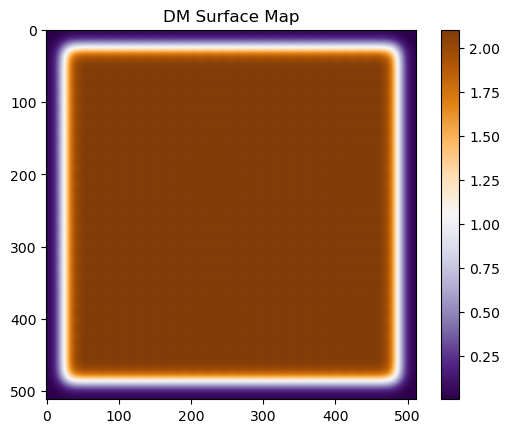

In [164]:
dm.actuators[:] = 1
sfe = dm.render(wfe=False)
plt.title("DM Surface Map")
plt.imshow(sfe, cmap="PuOr_r")
plt.colorbar()
dm.actuators[:] = 0

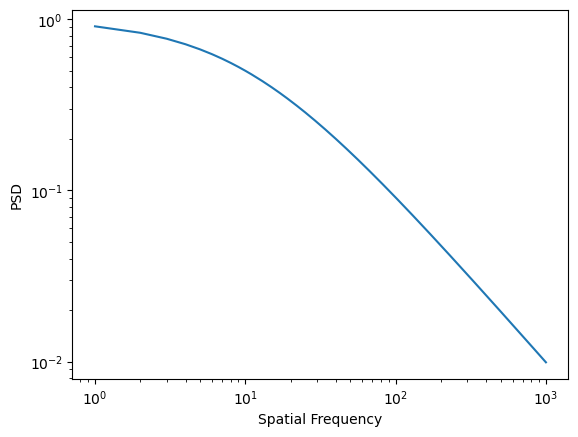

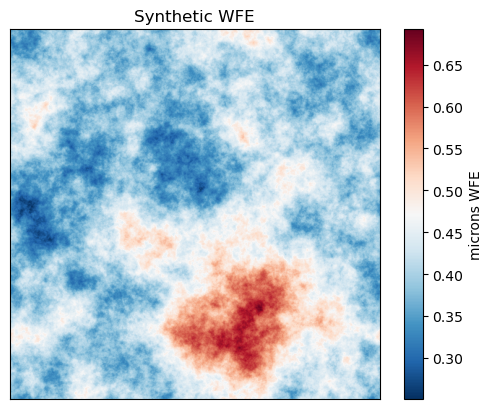

In [165]:
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=1, b=10, c=1)

plt.figure()
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.show()

# Just picked ABC values until it looked about right
Npup = Nout
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

plt.figure()
plt.title('Synthetic WFE')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

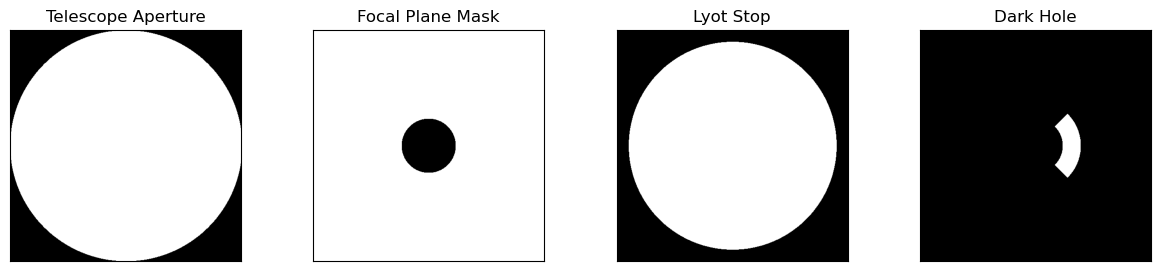

In [166]:
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)
A = circle(1, r)
LS = circle(0.9, r)

# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1/2 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL * z / 2) # with error

# Sample field
focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
IWA = 3
OWA = 5
CORO_IWA = 3
dark_hole[rho < OWA] = 1
dark_hole[rho < IWA] = 0
dark_hole[psi < -np.pi / 4] = 0
dark_hole[psi > np.pi / 4] = 0

FPM = np.ones_like(u)
FPM[ rho < CORO_IWA] = 0

focal_intensity = np.abs(focal)**2

plt.figure(figsize=[15,3])
plt.subplot(141)
plt.imshow(A, cmap='gray')
plt.xticks([],[])
plt.yticks([],[])
plt.title('Telescope Aperture')
plt.subplot(142)
plt.imshow(FPM, cmap='gray')
plt.title('Focal Plane Mask')
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(143)
plt.imshow(LS, cmap='gray')
plt.title('Lyot Stop')
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(144)
plt.imshow(dark_hole, cmap='gray')
plt.title('Dark Hole')
plt.xticks([],[])
plt.yticks([],[])
plt.show()

In [167]:
def snap_image(pupil_wfe=np.zeros_like(A), include_fpm=True):
    """take intensity image given a pupil wfe in microns

    Parameters
    ----------
    pupil_wfe : ndarray, optional
        wavefront error in microns, by default np.ones_like(A)
    """

    # create nominal wavefront
    wfe = np.exp(1j * 2 * np.pi / WVL * pupil_wfe)
    wvfnt_to_prop = wfe * wvfnt

    # propagate to focus
    focal = focus_fixed_sampling(wvfnt_to_prop,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    if include_fpm:
        focal *= FPM

    lyot = unfocus_fixed_sampling(focal,
                                input_dx=dx_img, # um
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=Dpup / wvfnt.shape[0], # mm
                                output_samples=wvfnt.shape[0])
    
    lyot *= LS

    coro = focus_fixed_sampling(lyot,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    return np.abs(coro)**2


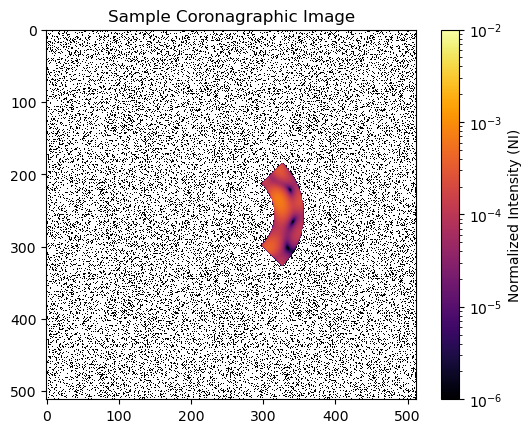

In [168]:
ref_contrast = snap_image(include_fpm=False).max()

plt.figure()
plt.title("Sample Coronagraphic Image")
plt.imshow(snap_image() / ref_contrast * dark_hole, cmap='inferno', norm=LogNorm(vmin=1e-6, vmax=1e-2))
plt.colorbar(label="Normalized Intensity (NI)")
plt.show()

# Set up iEFC

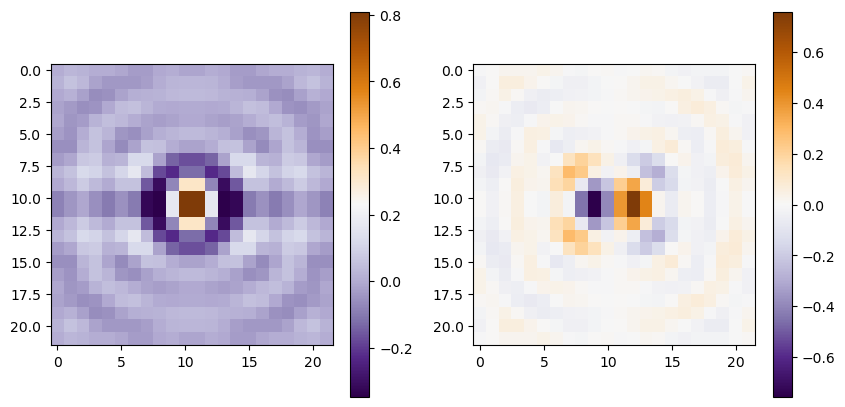

In [169]:
from poi.modes import poke_mode_sequence, fourier_modes_sequence

xact, yact = make_xy_grid(nact, dx=act_pitch)
rhoact, thact = cart_to_polar(xact, yact)
circ_dm_mask = np.ones_like(xact)

# Make Fourier Modes
cos_modes = fourier_modes_sequence(nact, dark_hole.shape[0], dx_img * um_to_LD, IWA, OWA, edge=1, which="cos")
sin_modes = fourier_modes_sequence(nact, dark_hole.shape[0], dx_img * um_to_LD, IWA, OWA, edge=1, which="sin")

cos_modes = np.sum(cos_modes, axis=0) / len(cos_modes)
sin_modes = np.sum(sin_modes, axis=0) / len(sin_modes)

modes = [-cos_modes, cos_modes, -sin_modes, sin_modes]

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.imshow(cos_modes, cmap="PuOr_r")
plt.colorbar()
plt.subplot(122)
plt.imshow(sin_modes, cmap="PuOr_r")
plt.colorbar()
plt.show()

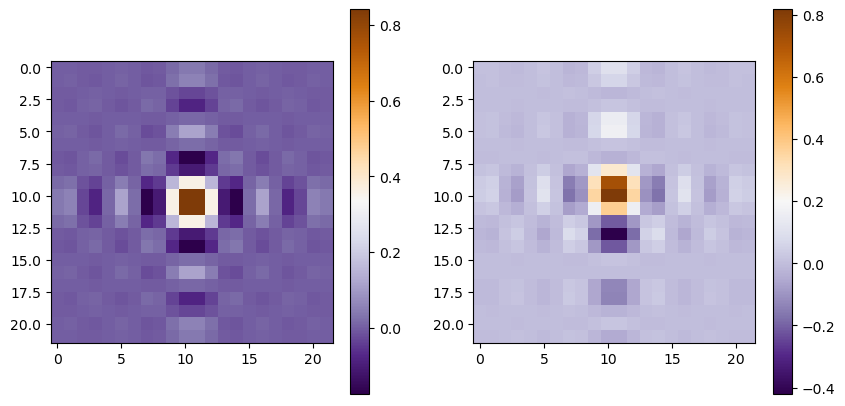

In [170]:
from poi.probes import create_sinc_probe, create_fourier_probes

amp = 1
probe_radius = 5 # is this L/D ?
shift = (0, 0)

dm_mask = np.ones([nact, nact])

probe1 = create_sinc_probe(Nacts=nact,
                          amp=amp,
                          probe_radius=probe_radius)

probe2 = create_sinc_probe(Nacts=nact,
                          amp=amp,
                          probe_radius=probe_radius,
                          offset=shift,
                          probe_phase=np.pi / 4)

# probe1, probe2 = create_fourier_probes(dm_mask, 256, dx_img * um_to_LD, iwa=IWA, owa=OWA)

# probe1 = np.zeros_like(probe1)
# probe1[5,5] = 1
# probe2 = np.zeros_like(probe2)
# probe2[5,7] = 1


plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.imshow(probe1, cmap="PuOr_r")
plt.colorbar()
plt.subplot(122)
plt.imshow(probe2, cmap="PuOr_r")
plt.colorbar()
plt.show()

In [171]:
from poi.efc import iEFC

iefc = iEFC(snap_image, dm, modes, [probe1, probe2], dark_hole,
            probe_amplitude=20e-3, # radians, change to 20nm
            mode_amplitude=20e-3,
            ref_contrast=ref_contrast)

In [172]:
from poi.processing import azimuthal_average
# try step forward
MAX_ITER = 50
energy = []
mean_in_dh = []
images = []
amplitudes = np.ones(MAX_ITER) * 10e-3
gains = np.ones(MAX_ITER)
recompute_jacobian = np.arange(MAX_ITER)
profiles = []
betas = np.ones(MAX_ITER) * -2.5

for i in range(MAX_ITER):
    if i in recompute_jacobian:
        iefc.calibrate()
        iefc.compute_control_matrix(beta=betas[i])
    img = iefc.step(loop_gain=gains[i])
    pro, bins = azimuthal_average(img)
    profiles.append(pro)

    # NOTE: Investigate whether this is actually changing
    iefc.probe_amplitude = amplitudes[i]
    iefc.mode_amplitude = amplitudes[i]

4it [00:01,  2.86it/s]


Taking starter image at position zero


4it [00:01,  2.80it/s]
4it [00:01,  3.00it/s]
4it [00:01,  2.96it/s]
4it [00:01,  2.93it/s]
4it [00:01,  2.94it/s]
4it [00:01,  2.90it/s]
4it [00:01,  2.90it/s]
4it [00:01,  2.94it/s]
4it [00:01,  2.84it/s]
4it [00:01,  2.96it/s]
4it [00:01,  2.59it/s]
4it [00:02,  1.96it/s]
4it [00:01,  2.01it/s]
4it [00:02,  1.98it/s]
4it [00:01,  2.32it/s]
4it [00:01,  2.62it/s]
4it [00:01,  2.59it/s]
4it [00:01,  2.73it/s]
4it [00:01,  2.79it/s]
4it [00:01,  2.68it/s]
4it [00:01,  2.45it/s]
4it [00:01,  2.72it/s]
4it [00:01,  2.82it/s]
4it [00:01,  2.73it/s]
4it [00:01,  2.79it/s]
4it [00:01,  2.79it/s]
4it [00:01,  2.78it/s]
4it [00:01,  2.63it/s]
4it [00:01,  2.75it/s]
4it [00:01,  2.82it/s]
4it [00:01,  2.71it/s]
4it [00:01,  2.85it/s]
4it [00:01,  2.77it/s]
4it [00:01,  2.79it/s]
4it [00:01,  2.75it/s]
4it [00:01,  2.60it/s]
4it [00:01,  2.67it/s]
4it [00:01,  2.80it/s]
4it [00:01,  2.89it/s]
4it [00:01,  2.66it/s]
4it [00:01,  2.78it/s]
4it [00:01,  2.83it/s]
4it [00:01,  2.54it/s]
4it [00:01,

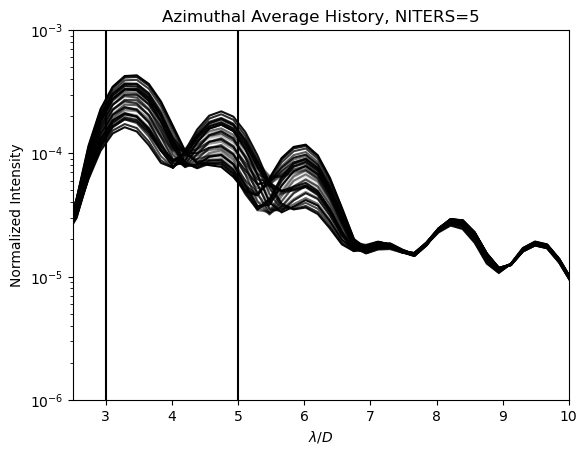

In [174]:
plt.figure()
plt.title(f"Azimuthal Average History, NITERS={i}")
starter_pro, bins = azimuthal_average(iefc.images[0])
# plt.plot(bins * dx_img * um_to_LD, starter_pro, color="k", alpha=1/2)
for i, pro in enumerate(profiles):
    plt.plot(bins * dx_img * um_to_LD, pro, color="k", alpha=(1/MAX_ITER)*(i+1))
    
plt.yscale("log")
plt.ylabel("Normalized Intensity")
plt.xlabel(r"$\lambda / D$")
plt.vlines(IWA, ymin=1e-7, ymax=1e-2, colors="k")
plt.vlines(OWA, ymin=1e-7, ymax=1e-2, colors="k")
plt.ylim([1e-6, 1e-3])
plt.xlim([2.5, 10])
plt.show()